## ***EXPOLATORY DATA ANALYSIS***

In [19]:
import pandas as pd
import seaborn as  sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import RandomOverSampler
from sklearn.impute import SimpleImputer


In [2]:
poland_df = pd.read_csv("data/poland_df.csv")
poland_df.head()

,Attr1,Attr2,Attr3,Attr4,Attr5,Attr6,Attr7,Attr8,Attr9,Attr10,...,Attr56,Attr57,Attr58,Attr59,Attr60,Attr61,Attr62,Attr63,Attr64,bankrupt
0,0.159290,0.46240,0.07773,1.1683,-44.853,0.467020,0.189480,0.82895,1.1223,0.38330,...,0.108990,0.41557,0.89101,0.001422,7.7928,4.9914,119.810,3.0465,3.0560,b'0'
1,-0.127430,0.46243,0.26917,1.7517,7.597,0.000925,-0.127430,1.16250,1.2944,0.53757,...,-0.089372,-0.23704,1.06250,0.150410,5.4327,3.4629,100.970,3.6150,3.4725,b'0'
2,0.070488,0.23570,0.52781,3.2393,125.680,0.163670,0.086895,2.87180,1.0574,0.67689,...,0.054286,0.10413,0.94571,0.000000,7.1070,3.3808,76.076,4.7978,4.7818,b'0'
3,0.136760,0.40538,0.31543,1.8705,19.115,0.504970,0.136760,1.45390,1.1144,0.58938,...,0.102630,0.23203,0.89737,0.073024,6.1384,4.2241,88.299,4.1337,4.6484,b'0'
4,-0.110080,0.69793,0.18878,1.2713,-15.344,0.000000,-0.110080,0.43282,1.7350,0.30207,...,0.439880,-0.36440,0.57153,0.000000,18.8010,2.7925,146.390,2.4934,15.0360,b'0'


# Getting nore information about the dataset
**This includes NaN Values, datatypes**

In [3]:
poland_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43405 entries, 0 to 43404
Data columns (total 65 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Attr1     43397 non-null  float64
 1   Attr2     43397 non-null  float64
 2   Attr3     43397 non-null  float64
 3   Attr4     43271 non-null  float64
 4   Attr5     43316 non-null  float64
 5   Attr6     43397 non-null  float64
 6   Attr7     43397 non-null  float64
 7   Attr8     43311 non-null  float64
 8   Attr9     43396 non-null  float64
 9   Attr10    43397 non-null  float64
 10  Attr11    43361 non-null  float64
 11  Attr12    43271 non-null  float64
 12  Attr13    43278 non-null  float64
 13  Attr14    43397 non-null  float64
 14  Attr15    43369 non-null  float64
 15  Attr16    43310 non-null  float64
 16  Attr17    43311 non-null  float64
 17  Attr18    43397 non-null  float64
 18  Attr19    43277 non-null  float64
 19  Attr20    43278 non-null  float64
 20  Attr21    37551 non-null  fl

# The target 


In [4]:
poland_df["bankrupt"].head()


0    b'0'
1    b'0'
2    b'0'
3    b'0'
4    b'0'
Name: bankrupt, dtype: object

In [5]:
#Making the target to have classes 0 and 1
poland_df["bankrupt"] = poland_df["bankrupt"].str.replace(r"b'|'", "", regex=True).astype(int)
poland_df["bankrupt"].head()

0    0
1    0
2    0
3    0
4    0
Name: bankrupt, dtype: int64

In [6]:
poland_df.tail()

,Attr1,Attr2,Attr3,Attr4,Attr5,Attr6,Attr7,Attr8,Attr9,Attr10,...,Attr56,Attr57,Attr58,Attr59,Attr60,Attr61,Attr62,Attr63,Attr64,bankrupt
43400,0.018371,0.47410,-0.13619,0.60839,-18.4490,0.018371,0.018371,0.972030,1.01210,0.460840,...,0.011909,0.039866,0.98809,0.27414,73.505,79.2370,31.268,11.6730,5.14890,1
43401,-0.013359,0.58354,-0.02265,0.92896,-42.2320,-0.013359,-0.015036,0.562890,0.98904,0.328470,...,-0.011082,-0.040671,1.01110,0.80592,10.599,7.1740,94.092,3.8792,1.75720,1
43402,0.006338,0.50276,0.43923,1.87360,9.7417,0.006338,0.012022,0.983560,1.00830,0.494490,...,0.008258,0.012817,0.99174,0.00000,10.470,6.0759,51.019,7.1542,62.00100,1
43403,-0.041643,0.84810,-0.12852,0.57485,-121.9200,0.000000,-0.036795,0.179010,0.42138,0.151820,...,-0.232720,-0.274290,0.98788,3.59310,39.703,3.1420,261.850,1.3939,0.51005,1
43404,0.014946,0.94648,0.03211,1.03630,-20.5810,0.000000,0.015260,0.056357,2.96940,0.053341,...,0.015705,0.280210,0.97443,1.17920,15.036,4.1741,108.640,3.3599,35.11800,1


# Class Distribution 

In [7]:
poland_df["bankrupt"].value_counts(normalize=True)

bankrupt
0    0.951826
1    0.048174
Name: proportion, dtype: float64

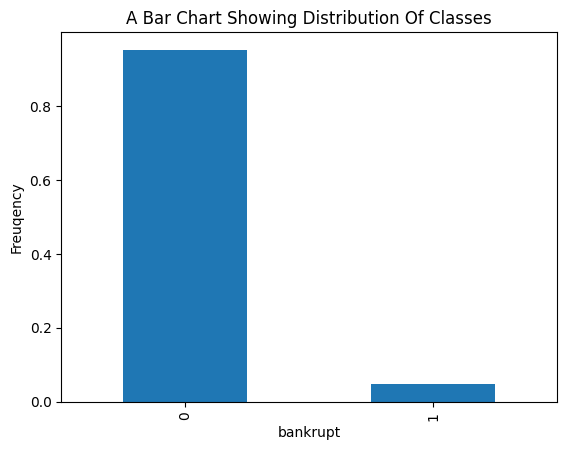

In [8]:
# A Plot showing Distribution of classes
poland_df["bankrupt"].value_counts(normalize=True).plot(kind="bar")
plt.title("A Bar Chart Showing Distribution Of Classes")
plt.ylabel("Freuqency");

***From the above we can conclude that with the given data more companies have no threat of running bankrupt whereas there are a few with chances of running bankrupt***

# The correlation heat map

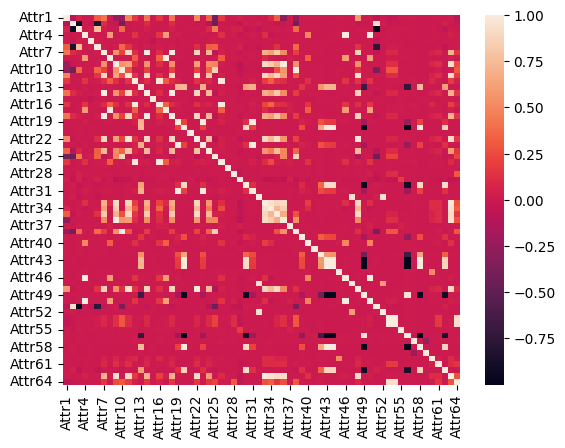

In [9]:
corr = poland_df.drop(columns="bankrupt").corr()
sns.heatmap(corr);

**Addressing Class Imbalance**

**1. The Oversampling Techniques**

In [10]:
#splitting the Data
X = poland_df.drop(columns="bankrupt")
y = poland_df["bankrupt"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [15]:
# Applying Random Oversampler on training data only
over_sampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = over_sampler.fit_resample(X_train, y_train)

In [18]:
#Checking for the escence of OverSampling
y_train_over.value_counts(normalize=True)

bankrupt
0    0.5
1    0.5
Name: proportion, dtype: float64

## BULIDING THE MODELS WTH DIFFERENT TECHNIQUES

In [22]:
model_reg = make_pipeline(
    SimpleImputer(strategy="median"), 
    DecisionTreeClassifier(random_state=42)) 
model_reg.fit(X_train,y_train) 
model_reg.fit(X_train_over,y_train_over)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('simpleimputer', ...), ('decisiontreeclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness desp